# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [49]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar Dataset

In [50]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [51]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `miembro_premium`
- `abandono`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
Las columnas `visitas_mes`, `compras_mes`, `miembro_premium`, `abandono` tienen numeros enteros, el resto de columnas numéricas tienen valores en decimales. 


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [52]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [53]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [54]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` 👤 

Rango: 18 a 75 años, media de 38 años
Distribución bastante equilibrada (mediana 38 ≈ media 38)

✅ Sin sesgo aparente, población adulta activa


- `nivel_ingreso`💰 

Media de ~30,000 con std de 9,833
Rango amplio: 8,000 a 74,790

⚠️ Alta variabilidad — posible segmentación de clientes por nivel socioeconómico


- `visitas_mes` 🌐

Promedio de 10 visitas/mes, rango de 1 a 25
Distribución simétrica (mediana 10 = media 10)

✅ Comportamiento estable de navegación


- `compras_mes` 🛒

Media de 1.2 compras/mes, pero el 25% compra 0 veces
Mediana en 1 — más de la mitad compra muy poco

⚠️ Base de clientes con baja conversión


- `gasto_publicidad_dirigida` 📢 

Media de 20.15, máximo de 75.51

⚠️ El 25% inferior recibe menos de 12.31 — inversión publicitaria muy desigual entre clientes


- `satisfaccion` ⭐

Escala aparente de 1 a 5, media de 3.6
Concentrada entre 3.1 y 4.1 (rango intercuartil)

✅ Satisfacción moderada-buena, pero con margen de mejora


👑 `miembro_premium`

Media de 0.139 → solo el ~14% es premium
Variable binaria (0/1)

⚠️ Baja adopción del programa premium — oportunidad de conversión


- `abandono`🚪

Media de 0.15 → tasa de churn del ~15%
Variable binaria (0/1)

⚠️ 1 de cada 7 clientes abandona — requiere atención en retención


- `ingreso_anual` 💵 

Media de 36.59, máximo de 244.69
Std de 34.48 — muy alta dispersión

⚠️ Distribución sesgada a la derecha: pocos clientes generan ingresos muy altos (posibles VIP)

#### Explorar variables binarias

In [55]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']

for col in columnas_binarias:
    valores = df[col].unique()
    print(f"{col}: {valores} → {len(valores)} valores únicos")

miembro_premium: [0 1] → 2 valores únicos
abandono: [0 1] → 2 valores únicos


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` —
Codificación correcta: 0 = No premium | 1 = Premium
Sin valores extraños ni corrupción de datos
✅ Lista para usar en modelos o segmentación

- `abandono` -
Codificación correcta: 0 = Se quedó | 1 = Abandonó
Sin valores nulos ni categorías inesperadas
✅ Lista para usar como variable objetivo en un modelo predictivo de churn

#### Explorar variables categóricas

In [56]:
# Verificar el número de valores únicos por variable categórica
df.select_dtypes(include='object').nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [57]:
# Explorar variables categóricas y cómo se distribuyen
categoricas = ['tipo_dispositivo', 'region']

for col in categoricas:
    print(f"\n{'='*45}")
    print(f"🔹 {col} — {df[col].nunique()} categorías")
    print(f"\n{df[col].value_counts()}")
    print(f"\nPorcentaje:")
    print(f"{df[col].value_counts(normalize=True).mul(100).round(2)}")


🔹 tipo_dispositivo — 3 categorías

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Porcentaje:
móvil         65.45
escritorio    24.80
tablet         9.75
Name: tipo_dispositivo, dtype: float64

🔹 region — 4 categorías

norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

Porcentaje:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — 3 categorías

Móvil = 9,818
      (65.45%)

Escritorio = 3,720
          (24.80%)
          
Tablet = 1,462
        (9.75%)

Hallazgos:

⚠️ Distribución desbalanceada — el móvil domina con casi 2/3 de los clientes. La tablet es el dispositivo menos usado, representando menos del 10%

🔴 Dato relevante: Si hay problemas de abandono o baja conversión, vale la pena cruzar esta variable con abandono y compras_mes — la experiencia móvil podría ser un factor clave

- `region` — 4 categorías
Norte = 4,395
        (29.30%)
  
Oeste = 3,810
        (25.40%)
        
Sur = 3,726
      (24.84%)
      
Este = 3,069
       (20.46%)
       
Hallazgos:

✅ Distribución bastante equilibrada entre las 4 regiones
La región Norte tiene ligera mayoría (29.3%)
La región Este es la menos representada (20.46%) — podría indicar menor penetración de mercado

🟡 Vale la pena cruzar con nivel_ingreso e ingreso_anual para ver si hay diferencias regionales

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

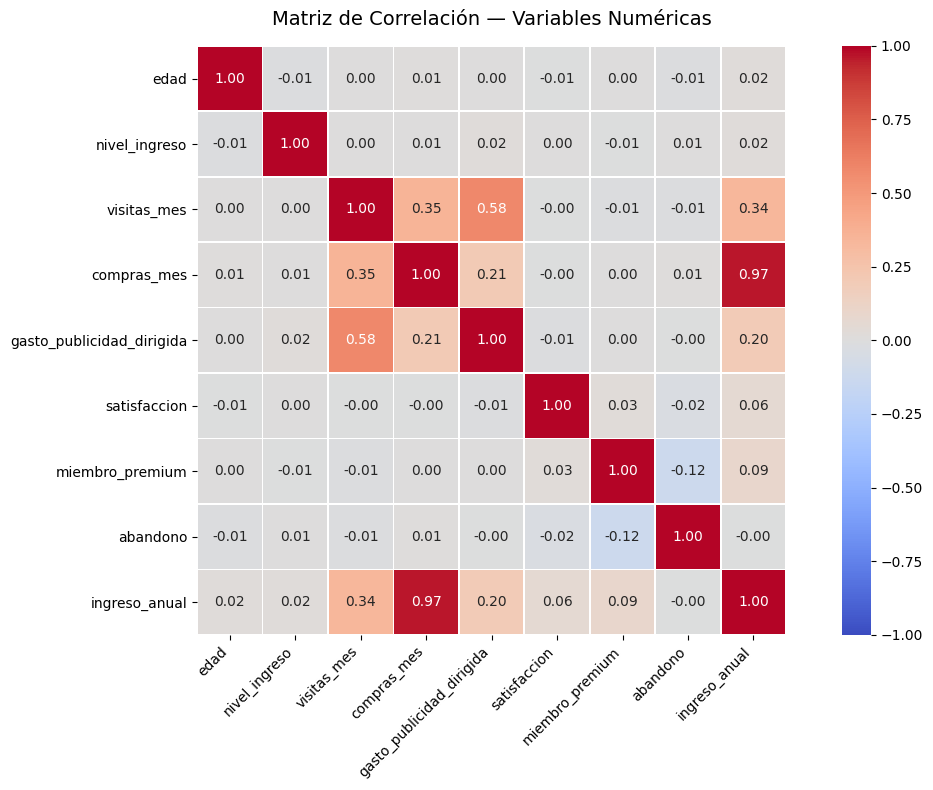

In [58]:
# Visualizar la matriz de correlación para identificar relaciones
# Seleccionar solo variables numéricas
numericas = df.select_dtypes(include=['float64', 'int64'])
numericas = numericas.drop(columns=['id_cliente'], errors='ignore')

# Calcular correlación
correlacion = numericas.corr()

# Graficar heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlacion, 
            annot=True,           # mostrar valores
            fmt='.2f',            # 2 decimales
            cmap='coolwarm',      # paleta de colores
            center=0,             # centrar en 0
            vmin=-1, vmax=1,      # rango de correlación
            linewidths=0.5,       # líneas entre celdas
            square=True)          # celdas cuadradas

plt.title('Matriz de Correlación — Variables Numéricas', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa una relación alta entre compras_mes e ingreso_anual del 0.97, tambien tenemos una correlación media entre gasto_publicidad_dirigida y visitas_mes del 0.58, lo que sugiere que la publicidad si ayuda a aumentar las visitas, una relación más pequeña entre compras_mes y visitas_mes de apenas el 0.35. Asimismo, la relación entre el gasto_publicidad_dirigida y las compras_mes es solo de un 0.21


Observaciones respecto a `ingreso_anual`  
- Presenta la correlación más fuerte del modelo con compras_mes. Existe una relación casi perfecta entre la cantidad de compras mensuales y el ingreso anual generado, lo cual es lógico y esperado — a mayor frecuencia de compra, mayor ingreso. Esto confirma que compras_mes es el principal driver de ingresos y será una variable clave en cualquier modelo predictivo.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.


**Decidí agregar el scatterplot general, pero de forma selectiva**

Un scatterplot de todas las variables con 9 variables numéricas generaría una matriz de 81 gráficos — visualmente saturada y poco útil.

Lo más eficiente es graficar únicamente los pares con correlaciones relevantes identificados en el heatmap.

### Scatterplot para pares clave

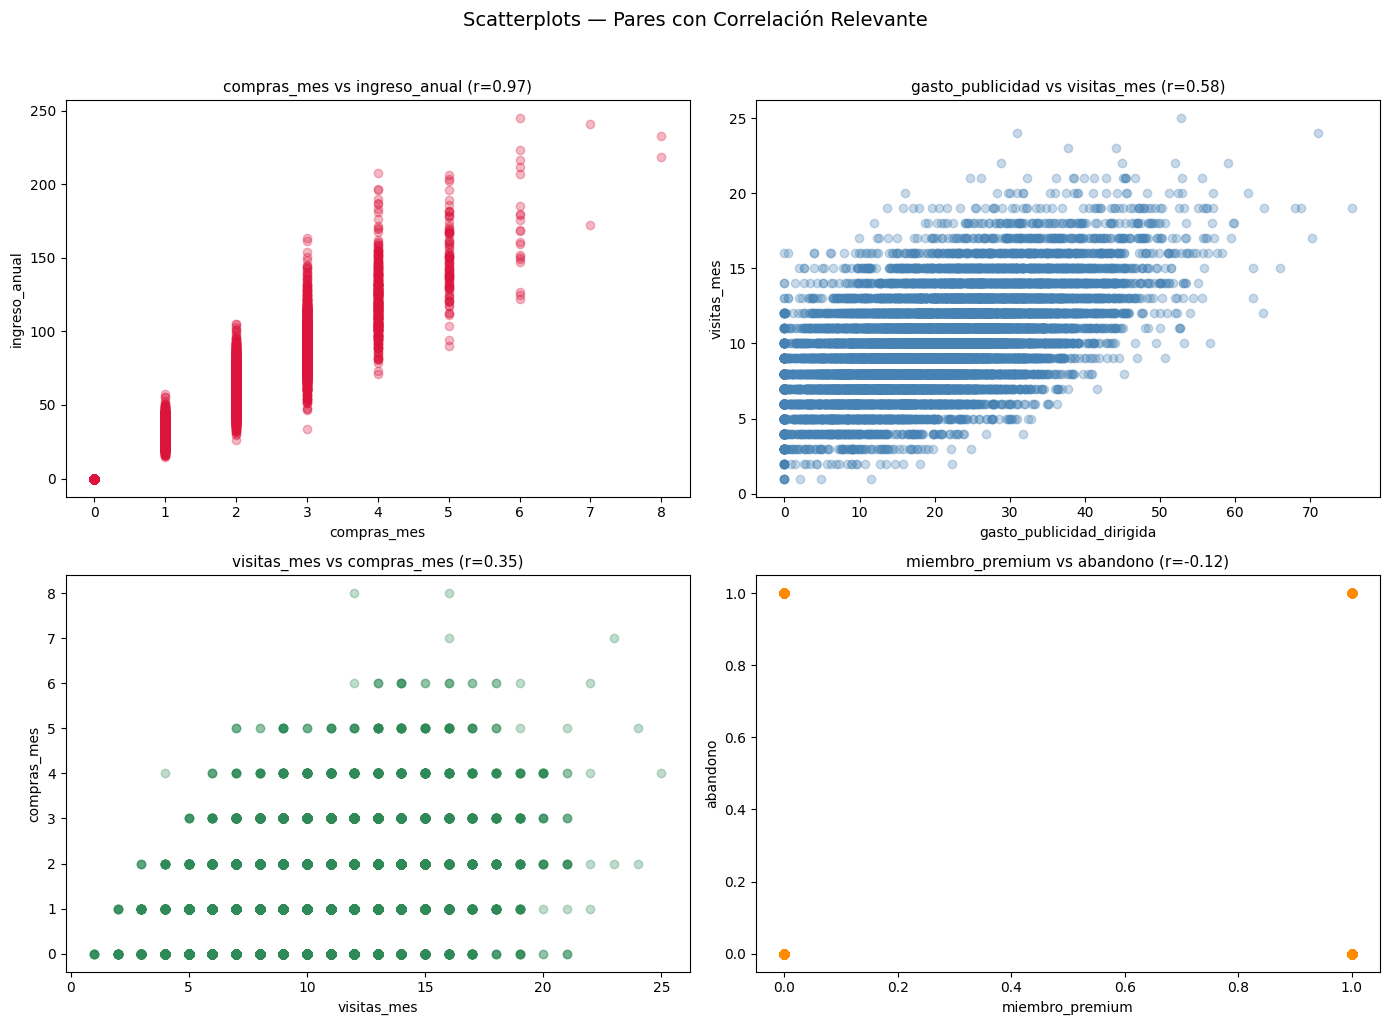

In [59]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Correlación alta
axes[0,0].scatter(df['compras_mes'], df['ingreso_anual'], 
                  alpha=0.3, color='crimson')
axes[0,0].set_title('compras_mes vs ingreso_anual (r=0.97)', fontsize=11)
axes[0,0].set_xlabel('compras_mes')
axes[0,0].set_ylabel('ingreso_anual')

# 2. Correlación media
axes[0,1].scatter(df['gasto_publicidad_dirigida'], df['visitas_mes'], 
                  alpha=0.3, color='steelblue')
axes[0,1].set_title('gasto_publicidad vs visitas_mes (r=0.58)', fontsize=11)
axes[0,1].set_xlabel('gasto_publicidad_dirigida')
axes[0,1].set_ylabel('visitas_mes')

# 3. Correlación baja-media
axes[1,0].scatter(df['visitas_mes'], df['compras_mes'], 
                  alpha=0.3, color='seagreen')
axes[1,0].set_title('visitas_mes vs compras_mes (r=0.35)', fontsize=11)
axes[1,0].set_xlabel('visitas_mes')
axes[1,0].set_ylabel('compras_mes')

# 4. Única correlación negativa notable
axes[1,1].scatter(df['miembro_premium'], df['abandono'], 
                  alpha=0.3, color='darkorange')
axes[1,1].set_title('miembro_premium vs abandono (r=-0.12)', fontsize=11)
axes[1,1].set_xlabel('miembro_premium')
axes[1,1].set_ylabel('abandono')

plt.suptitle('Scatterplots — Pares con Correlación Relevante', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

🔴 **compras_mes vs ingreso_anual** (r=0.97)

Dirección: Positiva muy fuerte

Dispersión: Baja — los puntos forman columnas verticales muy compactas por cada valor entero de compras

Outliers: Algunos puntos aislados en compras 4, 5 y 6 con ingresos inusualmente bajos (~$0-30), sugieren casos atípicos

Colinealidad: ⚠️ Alta — ambas variables miden esencialmente lo mismo. Si se usa un modelo predictivo, no deberían incluirse juntas como variables independientes

🔵 **gasto_publicidad_dirigida vs visitas_mes** (r=0.58)

Dirección: Positiva moderada

Dispersión: Alta — nube de puntos muy extendida horizontalmente, con visitas_mes tomando valores discretos (líneas horizontales visibles)

Outliers: Puntos dispersos en gastos superiores a $50 con visitas entre 1 y 25 sin patrón claro

Colinealidad: 🟡 Moderada — existe relación pero con suficiente independencia para usarlas juntas en un modelo

🟢 **visitas_mes vs compras_mes** (r=0.35)

Dirección: Positiva débil

Dispersión: Alta — para un mismo número de visitas (ej. 15), los clientes pueden tener entre 0 y 6 compras

Outliers: Fila de 0 compras muy poblada a lo largo de todo el rango de visitas — confirma el problema de conversión

Colinealidad: 🟢 Baja — pueden coexistir en un modelo sin problema

🟠 **miembro_premium vs abandono** (r=-0.12)

Dirección: Negativa muy débil

Dispersión: No aplica — al ser ambas variables binarias (0 y 1), solo existen 4 combinaciones posibles, visibles como 4 puntos en las esquinas

Outliers: No aplica por naturaleza binaria

Colinealidad: 🟢 Nula — variables independientes, sin riesgo de colinealidad

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [60]:
# Calcular correlación entre variables relevantes
from scipy import stats

pares = [
    ('compras_mes', 'ingreso_anual'),
    ('gasto_publicidad_dirigida', 'visitas_mes'),
    ('visitas_mes', 'compras_mes'),
    ('miembro_premium', 'abandono')
]

print(f"{'Par':<45} {'Pearson':>10} {'p-valor':>12} {'Spearman':>10} {'p-valor':>12}")
print("="*90)

for var1, var2 in pares:
    pearson_r,  p_pearson  = stats.pearsonr(df[var1], df[var2])
    spearman_r, p_spearman = stats.spearmanr(df[var1], df[var2])
    
    print(f"{var1+' vs '+var2:<45} {pearson_r:>10.4f} {p_pearson:>12.4f} {spearman_r:>10.4f} {p_spearman:>12.4f}")

Par                                              Pearson      p-valor   Spearman      p-valor
compras_mes vs ingreso_anual                      0.9671       0.0000     0.9675       0.0000
gasto_publicidad_dirigida vs visitas_mes          0.5789       0.0000     0.5593       0.0000
visitas_mes vs compras_mes                        0.3538       0.0000     0.3329       0.0000
miembro_premium vs abandono                      -0.1205       0.0000    -0.1205       0.0000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**🔴 compras_mes vs ingreso_anual**

Dirección: Positiva

Magnitud: Muy alta — Pearson (0.9671) y Spearman (0.9675) prácticamente idénticos

Significancia: p=0.0000 — estadísticamente significativo

Pearson ≈ Spearman: Confirma que la relación es lineal y libre de outliers influyentes

Colinealidad: ⚠️ Crítica — ambas variables miden lo mismo. En cualquier modelo predictivo deben usarse por separado, nunca juntas.

**🔵 gasto_publicidad_dirigida vs visitas_mes**

Dirección: Positiva

Magnitud: Moderada — Pearson (0.5789) ligeramente mayor que Spearman (0.5593)

Significancia: p=0.0000 — estadísticamente significativo

Pearson > Spearman: La diferencia sugiere que algunos outliers inflan levemente la correlación lineal

Colinealidad: 🟡 Moderada — existe relación real pero suficiente independencia para coexistir en un modelo

**🟢 visitas_mes vs compras_mes**

Dirección: Positiva

Magnitud: Baja-moderada — Pearson (0.3538) y Spearman (0.3329)

Significancia: p=0.0000 — estadísticamente significativo

Pearson > Spearman: Ligera influencia de outliers en la correlación lineal
Colinealidad: 🟢 Baja — variables independientes, seguras para usar juntas en modelos

Nota: Aunque significativa, la magnitud confirma el problema de conversión — muchas visitas no se traducen en compras.

**🟠 miembro_premium vs abandono**

Dirección: Negativa

Magnitud: Muy baja — Pearson y Spearman idénticos (-0.1205)

Significancia: p=0.0000 — estadísticamente significativo

Pearson = Spearman: Al ser variables binarias, ambos métodos producen el mismo resultado

Colinealidad: 🟢 Nula — la relación es débil pero real: ser premium reduce ligeramente la probabilidad de abandono

### Punto-biserial

In [62]:
# Calcular correlación entre variables relevantes
from scipy import stats

# Variables binarias vs variables continuas
binarias = ['abandono', 'miembro_premium']
continuas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
             'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

print(f"{'Par':<45} {'r_pb':>8} {'p-valor':>12} {'Significativo':>15}")
print("="*85)

for binaria in binarias:
    for continua in continuas:
        r_pb, p_valor = stats.pointbiserialr(df[binaria], df[continua])
        sig = '✅' if p_valor < 0.05 else '⚠️ No sig'
        print(f"{binaria+' vs '+continua:<45} {r_pb:>8.4f} {p_valor:>12.4f} {sig:>15}")
    print("-"*85)

Par                                               r_pb      p-valor   Significativo
abandono vs edad                               -0.0115       0.1590       ⚠️ No sig
abandono vs nivel_ingreso                       0.0059       0.4722       ⚠️ No sig
abandono vs visitas_mes                        -0.0089       0.2734       ⚠️ No sig
abandono vs compras_mes                         0.0083       0.3099       ⚠️ No sig
abandono vs gasto_publicidad_dirigida          -0.0046       0.5744       ⚠️ No sig
abandono vs satisfaccion                       -0.0238       0.0035               ✅
abandono vs ingreso_anual                      -0.0028       0.7295       ⚠️ No sig
-------------------------------------------------------------------------------------
miembro_premium vs edad                         0.0046       0.5728       ⚠️ No sig
miembro_premium vs nivel_ingreso               -0.0056       0.4930       ⚠️ No sig
miembro_premium vs visitas_mes                 -0.0127       0.1211       

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**abandono vs variables continuas**
- abandono vs satisfaccion (r=-0.0238) ✅

Dirección: Negativa

Magnitud: Muy baja

Interpretación: Clientes con menor satisfacción tienen una ligera tendencia a abandonar. Aunque significativo estadísticamente, el impacto práctico es muy limitado

- abandono vs edad, nivel_ingreso, visitas_mes, compras_mes, gasto_publicidad_dirigida, ingreso_anual ⚠️

Dirección: Mixta (algunas positivas, otras negativas)

Magnitud: Prácticamente nula (todos < 0.02)

Interpretación: El abandono no está explicado por ninguna variable numérica del dataset — sugiere que los factores que generan churn son cualitativos o no están siendo medidos

**miembro_premium vs variables continuas**

- miembro_premium vs ingreso_anual (r=0.0931) ✅

Dirección: Positiva

Magnitud: Baja pero es la más alta de toda la tabla

Interpretación: Clientes premium generan ligeramente más ingreso anual — tiene sentido dado que son clientes más comprometidos

- miembro_premium vs satisfaccion (r=0.0257) ✅

Dirección: Positiva

Magnitud: Muy baja

Interpretación: Los miembros premium reportan marginalmente mayor satisfacción, aunque la diferencia práctica es mínima

- miembro_premium vs edad, nivel_ingreso, visitas_mes, compras_mes, gasto_publicidad_dirigida ⚠️

Dirección: Mixta

Magnitud: Prácticamente nula (todos < 0.02)

Interpretación: El ser miembro premium no depende de variables demográficas ni de comportamiento de compra medidas en este dataset

### V de Cramér

In [63]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

In [64]:
# Aplicar V de Cramér en variables relevantes
def cramers_v(var1, var2):
    tabla = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    k = min(tabla.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    return round(v, 4), round(p, 4)

# Variables a comparar
pares_categoricos = [
    ('tipo_dispositivo', 'region'),
    ('tipo_dispositivo', 'abandono'),
    ('tipo_dispositivo', 'miembro_premium'),
    ('region', 'abandono'),
    ('region', 'miembro_premium')
]

print(f"{'Par':<45} {'V Cramér':>10} {'p-valor':>12} {'Significativo':>15}")
print("="*85)

for var1, var2 in pares_categoricos:
    v, p = cramers_v(var1, var2)
    sig = '✅' if p < 0.05 else '⚠️ No sig'
    print(f"{var1+' vs '+var2:<45} {v:>10.4f} {p:>12.4f} {sig:>15}")


Par                                             V Cramér      p-valor   Significativo
tipo_dispositivo vs region                        0.0124       0.5965       ⚠️ No sig
tipo_dispositivo vs abandono                      0.0072       0.6746       ⚠️ No sig
tipo_dispositivo vs miembro_premium               0.0197       0.0540       ⚠️ No sig
region vs abandono                                0.0154       0.3117       ⚠️ No sig
region vs miembro_premium                         0.0126       0.4989       ⚠️ No sig


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

Ninguna combinación de variables categóricas muestra asociación significativa. Esto refuerza el patrón observado a lo largo de todo el análisis de correlación:

region y tipo_dispositivo son variables independientes entre sí y respecto al comportamiento del cliente
El abandono y la membresía premium no están explicados por variables categóricas ni numéricas del dataset
Esto sugiere que los factores reales detrás del churn y la conversión premium podrían estar en variables no capturadas, como experiencia de usuario, historial de soporte o factores externos

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio
---

**Hallazgo 1 — Las compras mensuales son el principal motor de ingresos**

**Evidencia visual:**  
Scatterplot compras_mes vs ingreso_anual muestra una línea casi perfecta con puntos muy compactos por cada valor entero de compras.

**Evidencia numérica:** 
Pearson=0.9671, Spearman=0.9675, p=0.0000

**Interpretación**  
Existe una asociación casi perfecta entre la frecuencia de compra mensual y el ingreso anual generado. Clientes que compran más frecuentemente están fuertemente asociados con mayores ingresos.

**No podemos afirmar**  
Que aumentar artificialmente las compras causará directamente un aumento en ingresos, ni descartar que ambas variables sean manifestaciones de un mismo comportamiento subyacente.

**Implicación de negocio**  
Estrategias orientadas a incrementar la frecuencia de compra — como programas de fidelización, promociones recurrentes o suscripciones — podrían tener alto impacto en los ingresos. Es la palanca más poderosa identificada en el dataset.

**Hallazgo 2 — La publicidad dirigida se asocia con mayor tráfico, pero no con más compras**

**Evidencia visual:**  
Scatterplot gasto_publicidad_dirigida vs visitas_mes muestra nube de puntos con tendencia positiva moderada. Scatterplot gasto_publicidad_dirigida vs compras_mes muestra dispersión mucho mayor.

**Evidencia numérica:** 
Publicidad vs visitas: Pearson=0.5789 / Publicidad vs compras: Pearson=0.2100, p=0.0000 en ambos casos.

**Interpretación**  
El gasto publicitario está moderadamente asociado con un aumento en visitas, pero esta relación se debilita considerablemente al relacionarlo con compras efectivas.

**No podemos afirmar**  
Que la publicidad causa las visitas directamente, ni que reducir el gasto publicitario disminuirá el tráfico en la misma proporción.

**Implicación de negocio**  
Existe una brecha de conversión entre visita y compra que la publicidad no resuelve por sí sola. Invertir en optimización de la experiencia de compra podría ser más rentable que incrementar el presupuesto publicitario.

**Hallazgo 3 - Muchas visitas no se convierten en compras**

**Evidencia visual:**
Scatterplot visitas_mes vs compras_mes muestra una fila densa de clientes con 0 compras a lo largo de todo el rango de visitas.

**Evidencia numérica:** Pearson=0.3538, Spearman=0.3329, p=0.0000. Adicionalmente, la media de compras es apenas 1.2/mes con el 25% de clientes en 0 compras.

**Interpretación:** A pesar de visitar frecuentemente, una proporción importante de clientes no realiza ninguna compra. La relación entre visitas y compras existe pero es débil.

**No podemos afirmar:** Que aumentar las visitas incrementará las compras proporcionalmente, ni identificar con estos datos qué frena la conversión.

**Implicación de negocio:** Existe una oportunidad significativa en la optimización del embudo de conversión — mejorar la experiencia de compra, reducir fricciones en el proceso de pago o implementar estrategias de retargeting para visitantes recurrentes sin compras.

**Hallazgo 4 - La satisfacción es el único predictor significativo del abandono**

**Evidencia visual:**
No aplica — correlación demasiado baja para patrón visual claro.

**Evidencia numérica:**
Punto-biserial abandono vs satisfaccion: r=-0.0238, p=0.0035. Todas las demás variables vs abandono: p>0.05, no significativas.

**Interpretación:**
De todas las variables numéricas analizadas, la satisfacción es la única con asociación estadísticamente significativa con el abandono, aunque su magnitud es muy baja.

**No podemos afirmar:**
Que la baja satisfacción causa el abandono, ni que mejorar la satisfacción eliminará el churn. La magnitud (r=-0.02) sugiere que factores no medidos explican la mayor parte del abandono.

**Implicación de negocio:** El abandono parece ser un fenómeno multifactorial no capturado en el dataset actual. Se recomienda enriquecer el modelo con variables como historial de quejas, tiempo de respuesta de soporte o Net Promoter Score (NPS).

**Hallazgo 5 - Los miembros premium generan más ingreso anual**

**Evidencia visual:** 
No aplica — ambas variables tienen baja variabilidad visual conjunta.

**Evidencia numérica:**
Punto-biserial miembro_premium vs ingreso_anual: r=0.0931, p=0.0000. Es la correlación más alta entre variables binarias y continuas.

**Interpretación:**
Los clientes con membresía premium están asociados con un mayor ingreso anual, siendo esta la relación más relevante encontrada entre miembro_premium y cualquier variable continua.

**No podemos afirmar:** 
Que otorgar la membresía premium causará mayor ingreso, ni descartar que clientes con mayor ingreso simplemente tienen más propensión a adquirir la membresía.

**Implicación de negocio:** 
Incrementar la tasa de conversión al programa premium — actualmente en apenas el 14% — podría tener impacto positivo en los ingresos. Vale la pena investigar qué perfil de cliente tiene mayor probabilidad de convertirse en premium.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ Causalidad
Ninguna de las relaciones identificadas puede interpretarse como causa-efecto. El hecho de que compras y ingresos estén correlacionados no significa que una variable produzca la otra.
- Variables no capturadas
El dataset no incluye variables que probablemente explican el abandono, como historial de quejas, tiempo de respuesta del soporte, motivo de cancelación o Net Promoter Score (NPS).
- Variables binarias limitadas
abandono y miembro_premium al ser 0/1 restringen la profundidad del análisis correlacional — no permiten medir intensidad ni gradualidad del comportamiento.
- Desbalance en tipo_dispositivo
Con el 65% de registros en móvil, cualquier análisis segmentado por dispositivo estará sesgado hacia ese grupo, limitando conclusiones sobre tablet y escritorio.
- Ventana temporal desconocida
No se conoce el período que abarca el dataset, lo que impide identificar tendencias estacionales o cambios de comportamiento en el tiempo.
- Ausencia de variables de contexto
No hay información sobre competencia, campañas específicas, precios o categorías de producto que podrían explicar patrones observados.

### **Próximos pasos** 

Paso 1 — Probar segmentación adicional

Segmentar clientes por nivel de compras (0, 1-2, 3+ compras/mes) para identificar perfiles de comportamiento distintos
Segmentar por rango de ingreso para detectar diferencias en conversión y abandono entre niveles socioeconómicos

Paso 2 — Análisis de outliers

Identificar y tratar valores atípicos en ingreso_anual y nivel_ingreso, donde se observó alta dispersión
Evaluar si los outliers corresponden a clientes VIP o errores de captura antes de cualquier modelado

Paso 3 — Enriquecer el dataset

Incorporar variables cualitativas como motivo de cancelación, historial de soporte y NPS para mejorar la capacidad predictiva del abandono
Agregar dimensión temporal para detectar estacionalidad en visitas y compras

Paso 4 — Modelado predictivo

Desarrollar un modelo de predicción de churn usando abandono como variable objetivo
Construir un modelo de propensión a premium para identificar clientes con mayor probabilidad de conversión
Evaluar modelos de regresión, árbol de decisión y random forest dado el tamaño de muestra (n=15,000)

Paso 5 — Optimización de conversión

Analizar el embudo visita → compra para identificar en qué punto se pierde al cliente
Diseñar experimentos A/B para probar estrategias que reduzcan la brecha entre visitas y compras